In [47]:
!git clone https://github.com/yeonsumia/palmistry.git

Cloning into 'palmistry'...
remote: Enumerating objects: 262, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 262 (delta 10), reused 4 (delta 4), pack-reused 238 (from 3)
Receiving objects: 100% (262/262), 308.92 MiB | 25.35 MiB/s, done.
Resolving deltas: 100% (61/61), done.
Updating files: 100% (91/91), done.


In [48]:
%cd palmistry/code

/content/palmistry/code/palmistry/code


In [49]:
!ls

checkpoint	   input	   __pycache__	 rectification.py
classification.py  measurement.py  README.md	 requirements.txt
detection.py	   model.py	   read_palm.py  tools.py


In [50]:
!ls input

hand1.jpg  hand48.jpg  hand6.jpg  hand70.jpg


In [51]:
!cat requirements.txt

torch
torchvision
scikit-image
opencv-python
pillow-heif
mediapipe

In [52]:
!pip install -r requirements.txt

In [53]:
!ls checkpoint

checkpoint_aug_epoch70.pth


In [54]:
import torch
from model import UNet

In [55]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = UNet(3, 1)
checkpoint = torch.load(
    "checkpoint/checkpoint_aug_epoch70.pth",
    map_location=device
)
net.load_state_dict(checkpoint)
net.to(device)
net.eval()
print("Model load Successfully!")

Model load Successfully!


In [56]:
from detection import detect

In [57]:
!mkdir -p results

In [58]:
detect(
    net,
    "input/hand48.jpg",
    "results/prediction_hand48.png",
    256,
    device
)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

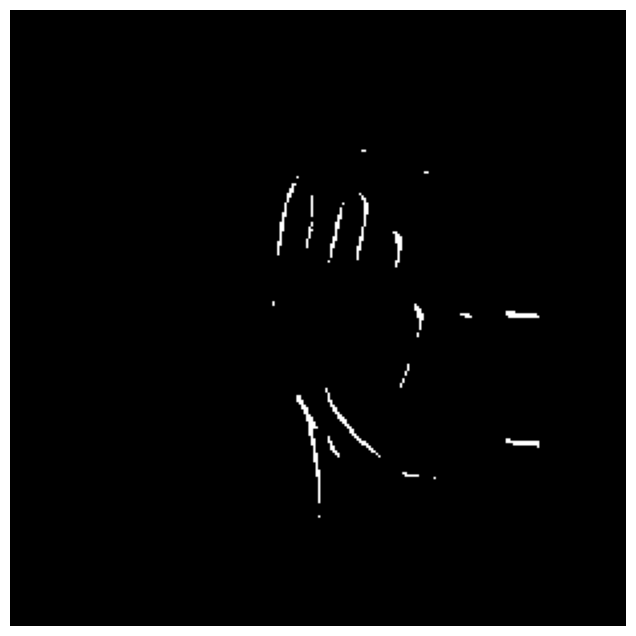

In [59]:
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(Image.open("results/prediction_hand48.png"))
plt.axis("off")

In [60]:
!head -80 read_palm.py

import os
import argparse
from tools import *
from model import *
from rectification import *
from detection import *
from classification import *
from measurement import *

def main(input):
    path_to_input_image = 'input/{}'.format(input)

    results_dir = './results'
    os.makedirs(results_dir, exist_ok=True)

    resize_value = 256
    path_to_clean_image = 'results/palm_without_background.jpg'
    path_to_warped_image = 'results/warped_palm.jpg'
    path_to_warped_image_clean = 'results/warped_palm_clean.jpg'
    path_to_warped_image_mini = 'results/warped_palm_mini.jpg'
    path_to_warped_image_clean_mini = 'results/warped_palm_clean_mini.jpg'
    path_to_palmline_image = 'results/palm_lines.png'
    path_to_model = 'checkpoint/checkpoint_aug_epoch70.pth'
    path_to_result = 'results/result.jpg'

    # 0. Preprocess image
    remove_background(path_to_input_image, path_to_clean_image)

    # 1. Palm image rectification
    warp_result = warp(path_to_input_image, path_to_warpe

In [61]:
!python read_palm.py --input hand48.jpg

Traceback (most recent call last):
  File "/content/palmistry/code/palmistry/code/read_palm.py", line 55, in <module>
    main(args.input)
  File "/content/palmistry/code/palmistry/code/read_palm.py", line 30, in main
    warp_result = warp(path_to_input_image, path_to_warped_image)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/palmistry/code/palmistry/code/rectification.py", line 56, in warp
    warp_result = warp_image(path_to_input_image, path_to_warped_image)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/palmistry/code/palmistry/code/rectification.py", line 34, in warp_image
    mp_hands = mp.solutions.hands
               ^^^^^^^^^^^^
AttributeError: module 'mediapipe' has no attribute 'solutions'


In [62]:
with open("rectification.py", "r") as f:
    print(f.read())

import numpy as np
import cv2
import mediapipe as mp

# code reference: https://google.github.io/mediapipe/solutions/hands.html

WARP_SUCCESS = 1

def warp_image(path_to_image, path_to_warped_image):
        # 7 landmark points (normalized)
    pts_index = list(range(21))
    pts_target_normalized = np.float32([[1-0.48203104734420776, 0.9063420295715332],
                                        [1-0.6043621301651001, 0.8119394183158875],
                                        [1-0.6763232946395874, 0.6790258884429932],
                                        [1-0.7340714335441589, 0.5716733932495117],
                                        [1-0.7896472215652466, 0.5098430514335632],
                                        [1-0.5655680298805237, 0.5117031931877136],
                                        [1-0.5979393720626831, 0.36575648188591003],
                                        [1-0.6135331392288208, 0.2713503837585449],
                                        [1-0.61964833

In [63]:
%%writefile rectification.py
import numpy as np
import cv2
import mediapipe as mp
import urllib.request

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

WARP_SUCCESS = 1
# Download MediaPipe Hand Landmarker model

MODEL_URL = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
MODEL_PATH = "hand_landmarker.task"

urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)



base_options = python.BaseOptions(
    model_asset_path=MODEL_PATH
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1
)

detector = vision.HandLandmarker.create_from_options(options)



def detect_landmarks(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return None

    image = cv2.flip(image, 1)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=image_rgb
    )

    detection_result = detector.detect(mp_image)

    if len(detection_result.hand_landmarks) == 0:
        return None

    return detection_result.hand_landmarks[0]





def warp_image(path_to_image, path_to_warped_image):

    pts_target_normalized = np.float32([
        [1-0.48203104734420776, 0.9063420295715332],
        [1-0.6043621301651001, 0.8119394183158875],
        [1-0.6763232946395874, 0.6790258884429932],
        [1-0.7340714335441589, 0.5716733932495117],
        [1-0.7896472215652466, 0.5098430514335632],
        [1-0.5655680298805237, 0.5117031931877136],
        [1-0.5979393720626831, 0.36575648188591003],
        [1-0.6135331392288208, 0.2713503837585449],
        [1-0.6196483373641968, 0.19251111149787903],
        [1-0.4928809702396393, 0.4982593059539795],
        [1-0.4899863600730896, 0.3213786780834198],
        [1-0.4894656836986542, 0.21283167600631714],
        [1-0.48334982991218567, 0.12900274991989136],
        [1-0.4258815348148346, 0.5180916786193848],
        [1-0.4033462107181549, 0.3581996262073517],
        [1-0.3938145041465759, 0.2616880536079407],
        [1-0.38608720898628235, 0.1775170862674713],
        [1-0.36368662118911743, 0.5642163157463074],
        [1-0.33553171157836914, 0.44737303256988525],
        [1-0.3209102153778076, 0.3749568462371826],
        [1-0.31213682889938354, 0.3026996850967407]
    ])


    image = cv2.imread(path_to_image)

    if image is None:
        return None


    image = cv2.flip(image, 1)

    image_height, image_width = image.shape[:2]


    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=image_rgb
    )


    detection_result = detector.detect(mp_image)

    if len(detection_result.hand_landmarks) == 0:
        return None

    hand_landmarks = detection_result.hand_landmarks[0]

    # 21 landmark points
    pts = np.float32([
        [lm.x * image_width, lm.y * image_height]
        for lm in hand_landmarks
    ])

    pts_target = np.float32([
        [x * image_width, y * image_height]
        for x, y in pts_target_normalized
    ])

    M, mask = cv2.findHomography(
        pts,
        pts_target,
        cv2.RANSAC,
        5.0
    )

    if M is None:
        return None

    warped_image = cv2.warpPerspective(
        image,
        M,
        (image_width, image_height),
        borderMode=cv2.BORDER_REPLICATE
    )

    cv2.imwrite(
        path_to_warped_image,
        warped_image
    )

    return WARP_SUCCESS


def warp(path_to_input_image, path_to_warped_image):

    if path_to_input_image[-4:] in ["heic", "HEIC"]:
        path_to_input_image = path_to_input_image[:-4] + "jpg"

    warp_result = warp_image(
        path_to_input_image,
        path_to_warped_image
    )

    if warp_result is None:
        return None

    return WARP_SUCCESS

Overwriting rectification.py


In [64]:
!python read_palm.py --input hand48.jpg

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1787032558.308923    8482 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787032558.324820    8481 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787032558.994865    8481 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
Traceback (most recent call last):
  File "/content/palmistry/code/palmistry/code/read_palm.py", line 55, in <module>
    main(args.input)
  File "/content/palmistry/code/palmistry/code/read_palm.py", line 43, in main
    lines = classify(path_to_palmline_image)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/palmistry/code/palmistry/code/classification.py",

In [65]:
!grep -n "skeletonize" classification.py

6:from skimage.morphology import skeletonize
316:            skel_img = cv2.cvtColor(skeletonize(img), cv2.COLOR_BGR2GRAY)
359:    skel_img = cv2.cvtColor(skeletonize(palmline_img), cv2.COLOR_BGR2GRAY)


In [66]:
%%writefile classification.py
import os
import glob
import numpy as np
import cv2
from PIL import Image
from skimage.morphology import skeletonize
import mediapipe as mp

#########################################################################################
# Sketch of idea                                                                        #
# - Build a graph : nodes = end pt. + intersection pt.                                  #
#                  edges = line segments (save pixel coordinates with next direction)   #
# - Find all possible paths(lines) from graph : graph backtracking                      #
# - Find three lines nearest to each cluster centers in feature space                   #
#   Find cluster centers using k-means clustering (k=3)                                 #
#########################################################################################

# code reference: https://google.github.io/mediapipe/solutions/hands.html
# data reference: https://drive.google.com/file/d/1B4uj-b4RuUNkC_oeCsRkuih4rjuQ6tHH/view

### 0. Load Data ###

# PLSU folder should exist in advance
# rectify images in PLSU folder
# find homography matrix using original image
# then apply homography matrix to detected line image
# input is the number 'idx' from image{idx}.jpg(.png)
def rectify(idx):
    img_path = './PLSU/PLSU/'
    image = cv2.imread(img_path + 'img/image' + str(idx) +'.jpg')
    image_mask = cv2.imread(img_path + 'Mask/image' + str(idx) + '.png', cv2.IMREAD_GRAYSCALE)
    mp_hands = mp.solutions.hands

    # 7 landmark points (normalized)
    pts_index = list(range(21))
    pts_target_normalized = np.float32([[1-0.48203104734420776, 0.9063420295715332],
                                        [1-0.6043621301651001, 0.8119394183158875],
                                        [1-0.6763232946395874, 0.6790258884429932],
                                        [1-0.7340714335441589, 0.5716733932495117],
                                        [1-0.7896472215652466, 0.5098430514335632],
                                        [1-0.5655680298805237, 0.5117031931877136],
                                        [1-0.5979393720626831, 0.36575648188591003],
                                        [1-0.6135331392288208, 0.2713503837585449],
                                        [1-0.6196483373641968, 0.19251111149787903],
                                        [1-0.4928809702396393, 0.4982593059539795],
                                        [1-0.4899863600730896, 0.3213786780834198],
                                        [1-0.4894656836986542, 0.21283167600631714],
                                        [1-0.48334982991218567, 0.12900274991989136],
                                        [1-0.4258815348148346, 0.5180916786193848],
                                        [1-0.4033462107181549, 0.3581996262073517],
                                        [1-0.3938145041465759, 0.2616880536079407],
                                        [1-0.38608720898628235, 0.1775170862674713],
                                        [1-0.36368662118911743, 0.5642163157463074],
                                        [1-0.33553171157836914, 0.44737303256988525],
                                        [1-0.3209102153778076, 0.3749568462371826],
                                        [1-0.31213682889938354, 0.3026996850967407]])

    with mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5) as hands:
        results = hands.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

        if results.multi_hand_landmarks == None: return np.zeros_like(image)
        image_height, image_width, _ = image.shape
        hand_landmarks = results.multi_hand_landmarks[0]
        pts = np.float32([[hand_landmarks.landmark[i].x*image_width,
                           hand_landmarks.landmark[i].y*image_height] for i in pts_index])
        pts_target = np.float32([[x*image_width, y*image_height] for x,y in pts_target_normalized])
        M, mask = cv2.findHomography(pts, pts_target, cv2.RANSAC,5.0)
        rectified_image = cv2.warpPerspective(image_mask, M, (image_width, image_height))
        pil_img = Image.fromarray(rectified_image)
        rectified_image = np.asarray(pil_img.resize((1024, 1024), resample=Image.NEAREST))
        return rectified_image

# load rectified data from PLSU to new folder
def load_data(num_data):
    # make directory
    data_path = './line_sample'
    result_path = './line_sample_result'
    path_list = [data_path, result_path]
    for path in path_list:
        os.makedirs(path, exist_ok=True)

    # count the current number of data
    cur_num_data = len(os.listdir(data_path))

    # load rectified data from PLSU data
    offset = 50
    img_path_list = [img_path for img_path in glob.glob('./PLSU/PLSU/Img/*')][offset+cur_num_data:offset+num_data]
    for i,img_path in enumerate(img_path_list):
        idx = img_path.split('image')[1].split('.')[0]
        rectified_image = rectify(idx)
        if np.sum(rectified_image)==0: continue
        cv2.imwrite('line_sample/image' + str(i+cur_num_data) + '.png', rectified_image)

### 1. Find possible lines ###

# connect seperated lines by gradient
# https://stackoverflow.com/questions/63727525/how-to-connect-broken-lines-that-can-not-be-connected-by-erosion-and-dilation
# https://stackoverflow.com/questions/43859750/how-to-connect-broken-lines-in-a-binary-image-using-python-opencv

# find all possible lines by graph backtracking
# lines_node : list of lines represented by nodes // ex. [[node0, ..., node3], ..., [node2, ..., node4]]
# temp : list of nodes up to now
# graph : node -> {adj. node -> line between two node} (dictionary type)
# visited_node : visited nodes up to now
# finished_node : visited nodes at least once
# node : current node
def backtrack(lines_node, temp, graph, visited_node, finished_node, node):
    end_pt = True
    for next_node in graph[node].keys():
        if not visited_node[next_node]:
            end_pt = False
            temp.append(next_node)
            visited_node[next_node] = True
            finished_node[next_node] = True
            backtrack(lines_node, temp, graph, visited_node, finished_node, next_node)
            del temp[-1]
            visited_node[next_node] = False
    # if there is no way to preceed, current node is the end node
    # add current line to the list
    if end_pt:
        line_node = []
        line_node.extend(temp)
        lines_node.append(line_node)

# find possible lines
# (1) build a graph
# (2) find all possible lines by graph backtracking
# (3) filter lines with length, direction criteria
def group(img):
    # (1) build a graph

    # (1)-1 find all nodes
    count = np.zeros(img.shape)
    nodes = []

    for j in range(1, img.shape[0] - 1):
        for i in range(1, img.shape[1] - 1):
            if img[j, i] == 0: continue
            count[j, i] = np.count_nonzero(img[j-1:j+2, i-1:i+2]) - 1
            if count[j, i] == 1 or count[j, i] >= 3:
                nodes.append((j, i))

    # sort nodes to traverse from upper-left to lower-right
    nodes.sort(key = lambda x : x[0]+x[1])

    # (1)-2 save all connections
    graph = dict()
    for node in nodes:
        graph[node] = dict()

    not_visited = np.ones(img.shape)
    for node in nodes:
        y,x = node
        not_visited[y, x] = 0
        around = np.multiply(count[y-1:y+2, x-1:x+2], not_visited[y-1:y+2, x-1:x+2])
        next_pos = np.transpose(np.nonzero(around))
        if next_pos.shape[0] == 0: continue
        for dy,dx in next_pos:
            y,x = node
            next_y = y + dy - 1
            next_x = x + dx - 1
            if dx == 0 or (dy == 0 and dx == 1):
                dy,dx = 2-dy,2-dx
            temp_line = [[y,x,0,0], [next_y,next_x,dy-1,dx-1]]
            if count[next_y, next_x] == 1 or count[next_y, next_x] >= 3:
                not_visited[next_y, next_x] = 1
                graph[tuple(temp_line[0][:2])][tuple(temp_line[-1][:2])] = temp_line
                temp_line_rev = list(reversed(temp_line))
                graph[tuple(temp_line[-1][:2])][tuple(temp_line[0][:2])] = temp_line_rev
                continue

            while(True):
                y,x = temp_line[-1][:2]
                not_visited[y, x] = 0
                around = np.multiply(count[y-1:y+2, x-1:x+2], not_visited[y-1:y+2, x-1:x+2])
                next_pos = np.transpose(np.nonzero(around))
                if next_pos.shape[0] == 0: break

                # update line
                next_y = y + next_pos[0][0] - 1
                next_x = x + next_pos[0][1] - 1
                dy,dx = next_y-y,next_x-x
                if dx == -1 or (dy == -1 and dx == 0):
                    dy,dx = -dy,-dx
                temp_line.append([next_y, next_x, dy, dx])
                not_visited[next_y, next_x] = 0

                # check end condition
                if count[next_y, next_x] == 1 or count[next_y, next_x] >= 3:
                    #if len(temp_line) > 10:
                    graph[tuple(temp_line[0][:2])][tuple(temp_line[-1][:2])] = temp_line
                    temp_line_rev = list(reversed(temp_line))
                    graph[tuple(temp_line[-1][:2])][tuple(temp_line[0][:2])] = temp_line_rev
                    not_visited[next_y, next_x] = 1
                    break
        not_visited[node[0], node[1]] = 1


    # (2) find all possible lines by graph backtracking
    lines_node = []
    visited_node = dict()
    finished_node = dict()
    for node in nodes:
        visited_node[node] = False
        finished_node[node] = False

    for node in nodes:
        if not finished_node[node]:
            temp = [node]
            visited_node[node] = True
            finished_node[node] = True
            backtrack(lines_node, temp, graph, visited_node, finished_node, node)

    # (3) filter lines with length, direction criteria
    lines = []
    for line_node in lines_node:
        num_node = len(line_node)
        if num_node == 1 : continue
        wrong = False
        line = []
        prev,cur = None,line_node[0]
        for i in range(1,num_node):
            nxt = line_node[i]
            # if the inner product of two connected line segments vectors is <0, discard it
            if i>1 and (cur[0]-prev[0])*(nxt[0]-cur[0])+(cur[1]-prev[1])*(nxt[1]-cur[1])<0:
                wrong = True
                break
            line.extend(graph[cur][nxt])
            prev,cur = cur,nxt
        # if the length is <10, discard it
        if wrong or len(line) < 10: continue
        lines.append(line)

    return lines

### 2. Choose three lines ###

# classify lines using l2 distance with centers in feature space
# remain at most 3 lines
def classify_lines(centers, lines, image_height, image_width):
    classified_lines = [None, None, None]
    line_idx = [None, None, None]
    nearest = [1e9, 1e9, 1e9]

    feature_list = np.empty((0,24))
    for line in lines:
        feature = extract_feature(line, image_height, image_width)
        feature_list = np.vstack((feature_list,feature))

    num_lines = len(lines)
    for i in range(3):
        center = centers[i]
        for j in range(num_lines):
            chosen = False
            for k in range(i-1):
                if line_idx[k]==j:
                    chosen = True
                    break
            if chosen: continue
            feature = feature_list[j]
            dist = np.linalg.norm(feature-center)
            if dist < nearest[i]:
                nearest[i] = dist
                classified_lines[i] = lines[j]
                line_idx[i] = j

    return classified_lines

### 3. Color each line ###

# color lines with BGR
def color(skel_img, lines):
    color_list = [[255,0,0], [0,255,0], [0,0,255]] # [B,G,R]

    num_lines = len(lines)
    colored_img = cv2.cvtColor(skel_img,cv2.COLOR_GRAY2RGB)
    for i in range(num_lines):
        line = lines[i]
        for y,x,_,_ in line:
            colored_img[y,x] = color_list[i]

    return colored_img


### Others ###

# extract feature from a line
def extract_feature(line, image_height, image_width):
    # feature = [min_y, min_x, max_y, max_x] + mean of direction info(dy,dx) * N intervals
    # => (2N+4)-dim
    image_size = np.array([image_height, image_width], dtype=np.float32)
    feature = np.append(np.min(line, axis=0)[:2]/image_size, np.max(line, axis=0)[:2]/image_size)
    feature *= 10
    N = 10
    step = len(line)//N
    for i in range(N):
        l = line[i*step:(i+1)*step]
        feature = np.append(feature, np.mean(l, axis=0)[2:])
    return feature


# find 3 cluster centers in feature space
# we can use pre-trained centers for testing
def get_cluster_centers(new_centers=False):
    if new_centers:
        # prepare good samples
        good = [12,104,193,212,220,249,256,295,304,396,402,487,698,908,992]
        for idx in good:
            rectified = rectify(idx)
            cv2.imwrite("good_sample/image"+str(idx)+".png",rectified)

        # put all data in feature space
        data = np.empty((0,24))
        for img_path in glob.glob("good_sample/*.png"):
            img = cv2.imread(img_path)
            skel_img = cv2.cvtColor((skeletonize(img)*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
            lines = group(skel_img)
            for line in lines:
                feature = extract_feature(line, 1024, 1024)
                data = np.vstack((data,feature))

        # k-means clustering (k=3)
        criteria = (cv2.TERM_CRITERIA_EPS|cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
        ret, label, centers = cv2.kmeans(data.astype(np.float32), 3, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

        # sort centers according to max_y
        centers = list(centers)
        centers.sort(key = lambda x : x[2])
    else:
        centers = [np.array([5.232849  , 4.881592  , 6.3223267 , 6.64093   , 0.8113839 ,
                            0.655735  , 0.82874316, 0.74796075, 0.7993417 , 0.8345605 ,
                            0.68143266, 0.90320605, 0.5769709 , 0.9721149 , 0.53258324,
                            0.98307294, 0.4804058 , 0.9829783 , 0.36796156, 0.99141085,
                            0.24345541, 0.99082345, 0.30017138, 0.9736235 ], dtype=np.float32),
                     np.array([5.645419  , 4.169626  , 7.126243  , 6.0026045 , 0.3532842 ,
                            0.928315  , 0.4692493 , 0.9680717 , 0.578683  , 0.9680221 ,
                            0.7227269 , 0.9454175 , 0.7741767 , 0.9495983 , 0.7802345 ,
                            0.89685285, 0.8743354 , 0.85625464, 0.82669544, 0.88459945,
                            0.8000444 , 0.8956431 , 0.74734426, 0.0], dtype=np.float32),
                     np.array([5.755994  , 3.8910964 , 8.680631  , 5.3926454 , 0.4247846 ,
                            0.93111324, 0.6940754 , 0.9203782 , 0.8567455 , 0.767301  ,
                            0.9177662 , 0.6054738 , 0.9801044 , 0.47111732, 0.9812451 ,
                            0.34593108, 0.97122467, 0.28715244, 0.9036454 , 0.26124895,
                            0.8069528 , 0.25324377, 0.59989274, 0.32016128], dtype=np.float32)]
    return centers

def classify(path_to_palmline_image):
    # load (rectified) test data
    # num_data = 10
    # load_data(num_data)

    # get cluster centers
    centers = get_cluster_centers()

    palmline_img = cv2.imread(path_to_palmline_image)
    kernel = np.ones((3, 3), np.uint8)
    # dilated = cv2.dilate(palmline_img, kernel, iterations=3)
    # eroded = cv2.erode(dilated, kernel, iterations=3)
    skel_img = cv2.cvtColor((skeletonize(palmline_img)*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)

    #cv2.imwrite('results/skel.jpg',skel_img)

    lines = group(skel_img)  # get candidate lines
    lines = classify_lines(centers, lines, palmline_img.shape[0], palmline_img.shape[1])  # choose 3 lines from candidates
    # colored_img = color(skel_img, classified_lines) # color 3 lines (RGB)

    return lines

Overwriting classification.py


In [67]:
!python read_palm.py --input hand48.jpg

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1787032568.984742    8554 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787032569.009047    8554 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787032569.987928    8554 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
Traceback (most recent call last):
  File "/content/palmistry/code/palmistry/code/read_palm.py", line 55, in <module>
    main(args.input)
  File "/content/palmistry/code/palmistry/code/read_palm.py", line 46, in main
    im, contents = measure(path_to_warped_image_mini, lines)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/palmistry/code/pa

In [68]:
!cat classification.py

import os
import glob
import numpy as np
import cv2
from PIL import Image
from skimage.morphology import skeletonize
import mediapipe as mp

#########################################################################################
# Sketch of idea                                                                        #
# - Build a graph : nodes = end pt. + intersection pt.                                  #
#                  edges = line segments (save pixel coordinates with next direction)   #
# - Find all possible paths(lines) from graph : graph backtracking                      #
# - Find three lines nearest to each cluster centers in feature space                   #
#   Find cluster centers using k-means clustering (k=3)                                 #
#########################################################################################

# code reference: https://google.github.io/mediapipe/solutions/hands.html
# data reference: https://drive.google.com/file/d/1B4uj-b4RuUNkC

In [69]:
!python read_palm.py --input hand48.jpg

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1787032579.601996    8635 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787032579.620374    8635 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787032580.494480    8634 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
Traceback (most recent call last):
  File "/content/palmistry/code/palmistry/code/read_palm.py", line 55, in <module>
    main(args.input)
  File "/content/palmistry/code/palmistry/code/read_palm.py", line 46, in main
    im, contents = measure(path_to_warped_image_mini, lines)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/palmistry/code/pa

In [70]:
%%writefile measurement.py
import cv2
import mediapipe as mp
from PIL import Image, ImageDraw
import urllib.request
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Download MediaPipe Hand Landmarker model
MODEL_URL = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
MODEL_PATH = "hand_landmarker.task"

urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)
detector = vision.HandLandmarker.create_from_options(options)

def measure(path_to_warped_image_mini, lines):
    heart_thres_x = 0
    head_thres_x = 0
    life_thres_y = 0

    image = cv2.imread(path_to_warped_image_mini)
    if image is None:
        return None, None

    image = cv2.flip(image, 1)
    image_height, image_width, _ = image.shape

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = detector.detect(mp_image)

    if len(detection_result.hand_landmarks) == 0:
        return None, None

    hand_landmarks = detection_result.hand_landmarks[0]

    # Using the landmark indices from mediapipe.tasks.python.vision.HandLandmarker.HandLandmark
    zero = hand_landmarks[0].y
    one = hand_landmarks[1].y
    five = hand_landmarks[5].x
    nine = hand_landmarks[9].x
    thirteen = hand_landmarks[13].x

    heart_thres_x = image_width * (1 - (nine + (five - nine) * 2 / 5))
    head_thres_x = image_width * (1 - (thirteen + (nine - thirteen) / 3))
    life_thres_y = image_height * (one + (zero - one) / 3)

    im = Image.open(path_to_warped_image_mini)
    width = 3
    if (None in lines) or (len(lines) < 3):
        return None, None
    else:
        draw = ImageDraw.Draw(im)

        heart_line = lines[0]
        head_line = lines[1]
        life_line = lines[2]

        heart_line_points = [tuple(reversed(l[:2])) for l in heart_line]
        heart_line_tip = heart_line_points[0]
        heart_content_1 = 'Love line governs all matters of the heart, including romance, friendship, and commitment.'
        if heart_line_tip[0] < heart_thres_x:
            heart_content_2 = 'Your Heart line is long, which means you will have long partnership with whom you love or care.'
        else:
            heart_content_2 = 'Your Heart line is short, which means you will meet various people and have a broad range of relationships throughout your life.'
        draw.line(heart_line_points, fill="red", width=width)

        head_line_points = [tuple(reversed(l[:2])) for l in head_line]
        head_line_tip = head_line_points[-1]
        head_content_1 = 'Head line tells us about our intellectual curiosities and pursuits.'
        if head_line_tip[0] > head_thres_x:
            head_content_2 = 'Your Head line is long, which means you will explore a broad range of topics throughout your life.'
        else:
            head_content_2 = 'Your Head line is short, which means you will be fascinated by one topic and dig deep into it.'
        draw.line(head_line_points, fill="green", width=width)

        life_line_points = [tuple(reversed(l[:2])) for l in life_line]
        life_line_tip = life_line_points[-1]
        life_content_1 = 'Life line reveals your experiences, vitality, and zest. Be careful, it has nothing to do with how long you will live!'
        if life_line_tip[1] > life_thres_y:
            life_content_2 = 'Your Life line is long, which means you tend to solve problems with other people rather than by yourself.'
        else:
            life_content_2 = 'Your Life line is short, which means you are independent and autonomous.'
        draw.line(life_line_points, fill="blue", width=width)

        contents = [heart_content_1, heart_content_2, head_content_1, head_content_2, life_content_1, life_content_2]
        return im, contents

Overwriting measurement.py


In [71]:
!python read_palm.py --input hand48.jpg

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1787032590.821102    8712 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787032590.836271    8711 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787032590.980309    8716 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787032590.995323    8715 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787032591.647427    8712 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
I0000 00:0

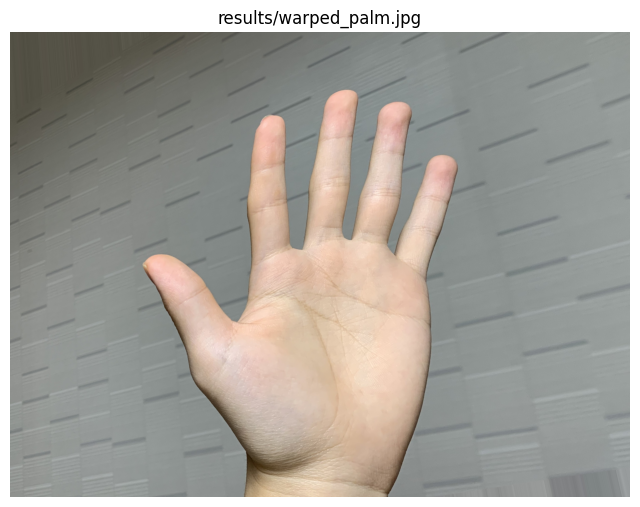

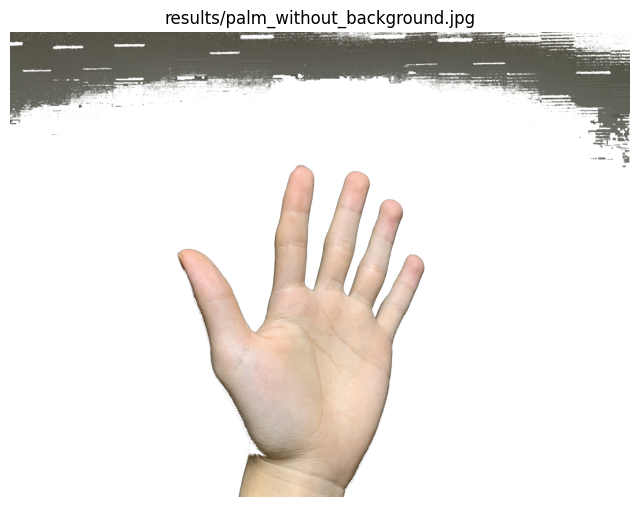

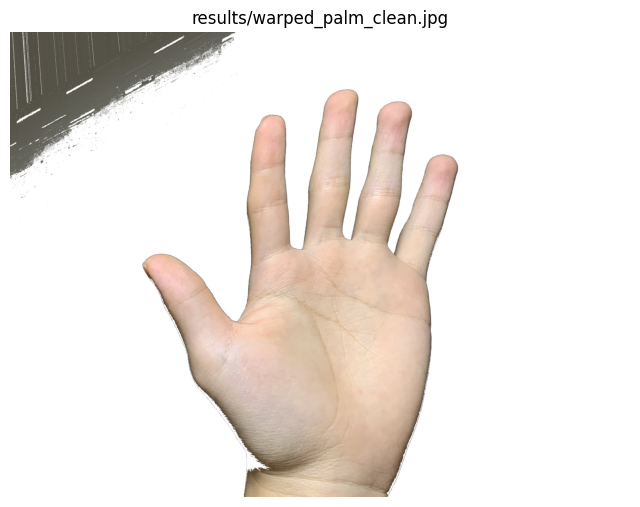

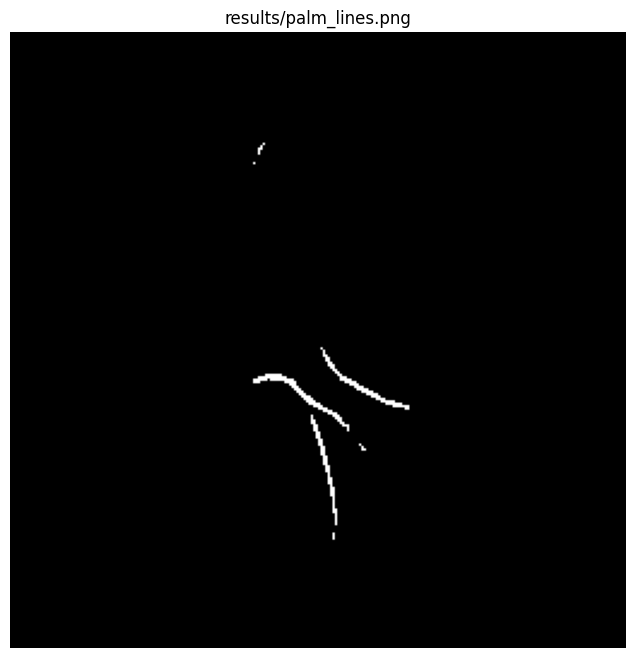

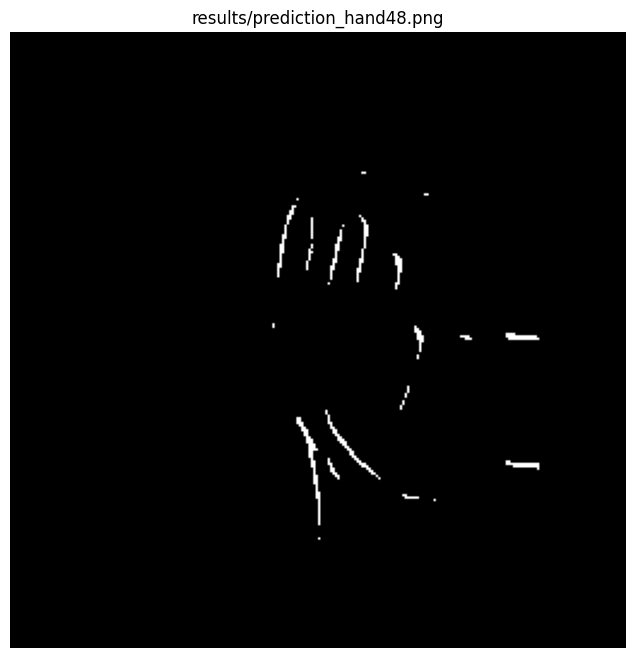

In [72]:
from PIL import Image
import matplotlib.pyplot as plt

files = [
    "results/warped_palm.jpg",
    "results/palm_without_background.jpg",
    "results/warped_palm_clean.jpg",
    "results/palm_lines.png",
    "results/prediction_hand48.png"
]

for f in files:
    plt.figure(figsize=(8,8))
    plt.imshow(Image.open(f))
    plt.title(f)
    plt.axis("off")
    plt.show()

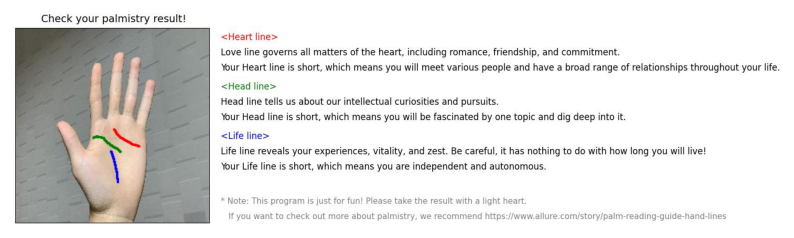

In [73]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("./results/result.jpg")

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.show()

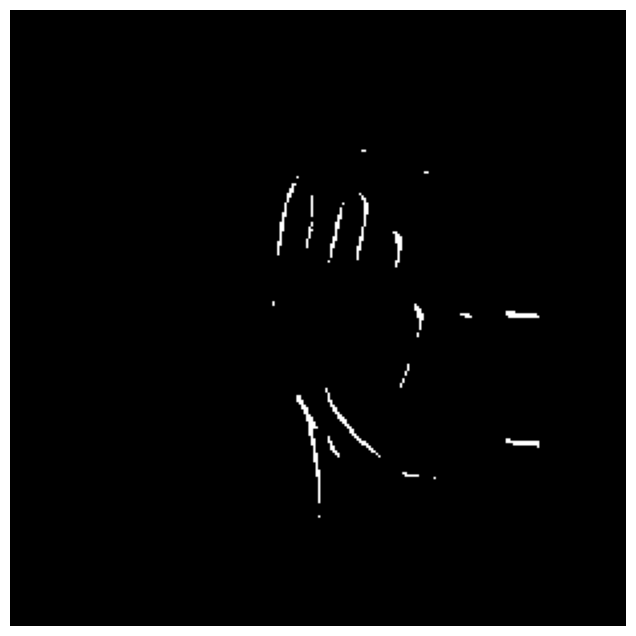

In [74]:
import cv2
import matplotlib.pyplot as plt

pred = cv2.imread("./results/prediction_hand48.png",0)

plt.figure(figsize=(8,8))
plt.imshow(pred,cmap="gray")
plt.axis("off")
plt.show()

In [75]:
import cv2
import numpy as np
from skimage.morphology import skeletonize

palmline_img = cv2.imread("./results/palm_lines.png")
if palmline_img is not None:
    # Ensure the image is processed correctly before skeletonize
    # skeletonize expects a binary image (True/False or 0/1)
    # Assuming palmline_img is already a binary-like image where lines are non-zero.
    # Convert to boolean for skeletonize, then back to uint8 for cvtColor if needed.
    # Given previous context, it was an issue with (skeletonize(img)*255).astype(np.uint8)
    # Let's recreate skel_img similar to how it's done in classification.py
    skel_img_bool = skeletonize(palmline_img > 0) # Convert to boolean for skeletonize
    skel_img = (skel_img_bool * 255).astype(np.uint8) # Convert back to uint8 (0 or 255)
    skel_img = cv2.cvtColor(skel_img, cv2.COLOR_BGR2GRAY) # Convert to grayscale if it's still BGR

    print("skel_img shape:", skel_img.shape)
    print("skel_img dtype:", skel_img.dtype)
else:
    print("Error: Could not load results/palm_lines.png. Please ensure read_palm.py ran successfully.")

skel_img shape: (256, 256)
skel_img dtype: uint8


In [76]:
!python read_palm.py --input hand48.jpg

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1787032605.038538    8808 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787032605.054030    8808 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787032605.195156    8812 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787032605.210590    8812 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787032605.994758    8808 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


In [77]:
!pip -q install groq

In [78]:
from groq import Groq

In [79]:
from google.colab import userdata
from groq import Groq

# Ensure you have added your GROQ_API_KEY to Colab secrets.
# Go to the 'Secrets' tab (lock icon 🔒) on the left sidebar,
# click '+ New secret', and add 'GROQ_API_KEY' with your actual API key.
GROQ_API_KEY = userdata.get("Groq_API_keys")

client = Groq(api_key=GROQ_API_KEY)

print("Groq API key loaded successfully.")

Groq API key loaded successfully.


In [80]:
import sys
import os
import torch
import cv2
import numpy as np
from PIL import Image

# Add project code directory
if '/content/palmistry/code' not in sys.path:
    sys.path.append('/content/palmistry/code')

# Project modules
from model import UNet
from rectification import warp
from detection import detect
from classification import classify
from measurement import measure
from tools import remove_background, resize, save_result

# Groq
from groq import Groq

Device: cuda
UNet model loaded successfully.

1. Removing background...
Background removal completed.

2. Rectifying palm...
Palm rectification completed.

3. Preparing palm images...
Palm resizing completed.

4. Detecting palm lines...
Palm line detection completed.

5. Classifying palm lines...
Palm line classification completed.

6. Measuring palm lines...
Palm measurement completed.
Palm result saved.

PALM ANALYSIS RESULT
Love line governs all matters of the heart, including romance, friendship, and commitment.
Your Heart line is short, which means you will meet various people and have a broad range of relationships throughout your life.
Head line tells us about our intellectual curiosities and pursuits.
Your Head line is long, which means you will explore a broad range of topics throughout your life.
Life line reveals your experiences, vitality, and zest. Be careful, it has nothing to do with how long you will live!
Your Life line is short, which means you are independent and aut

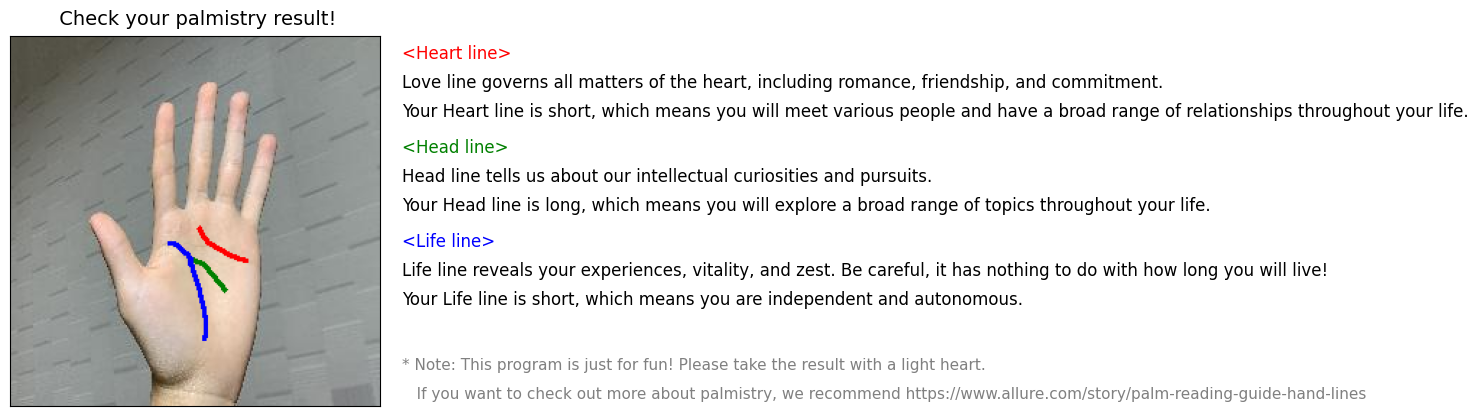

In [81]:
client = Groq(api_key=GROQ_API_KEY)

import os
import torch


path_to_input_image = '/content/palmistry/code/input/hand48.jpg'

results_dir = '/content/palmistry/code/results'
os.makedirs(results_dir, exist_ok=True)

resize_value = 256

path_to_clean_image = os.path.join(
    results_dir,
    'palm_without_background.jpg'
)

path_to_warped_image = os.path.join(
    results_dir,
    'warped_palm.jpg'
)

path_to_warped_image_clean = os.path.join(
    results_dir,
    'warped_palm_clean.jpg'
)

path_to_warped_image_mini = os.path.join(
    results_dir,
    'warped_palm_mini.jpg'
)

path_to_warped_image_clean_mini = os.path.join(
    results_dir,
    'warped_palm_clean_mini.jpg'
)

path_to_palmline_image = os.path.join(
    results_dir,
    'palm_lines.png'
)

path_to_model = (
    '/content/palmistry/code/checkpoint/'
    'checkpoint_aug_epoch70.pth'
)

path_to_result = os.path.join(
    results_dir,
    'result.jpg'
)


# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ------------------------------------------------------------
# LOAD UNET MODEL
# ------------------------------------------------------------

net = UNet(3, 1)

checkpoint = torch.load(
    path_to_model,
    map_location=device
)

net.load_state_dict(checkpoint)

net.to(device)
net.eval()

print("UNet model loaded successfully.")


# ------------------------------------------------------------
# STEP 1: REMOVE BACKGROUND
# ------------------------------------------------------------

print("\n1. Removing background...")

remove_background(
    path_to_input_image,
    path_to_clean_image
)

print("Background removal completed.")


# ------------------------------------------------------------
# STEP 2: WARP / RECTIFY PALM
# ------------------------------------------------------------

print("\n2. Rectifying palm...")

warp_result = warp(
    path_to_input_image,
    path_to_warped_image
)

if warp_result is None:

    print("Palm could not be detected.")

    contents = [
        "No palm detected. Please provide a clear image of a hand."
    ]

else:

    print("Palm rectification completed.")


    # --------------------------------------------------------
    # STEP 3: CLEAN + RESIZE
    # --------------------------------------------------------

    print("\n3. Preparing palm images...")

    remove_background(
        path_to_warped_image,
        path_to_warped_image_clean
    )

    resize(
        path_to_warped_image,
        path_to_warped_image_clean,
        path_to_warped_image_mini,
        path_to_warped_image_clean_mini,
        resize_value
    )

    print("Palm resizing completed.")


    # --------------------------------------------------------
    # STEP 4: DETECT PALM LINES
    # --------------------------------------------------------

    print("\n4. Detecting palm lines...")

    detect(
        net,
        path_to_warped_image_clean,
        path_to_palmline_image,
        resize_value,
        device
    )

    print("Palm line detection completed.")


    # --------------------------------------------------------
    # STEP 5: CLASSIFY LINES
    # --------------------------------------------------------

    print("\n5. Classifying palm lines...")

    lines = classify(
        path_to_palmline_image
    )

    print("Palm line classification completed.")


    # --------------------------------------------------------
    # STEP 6: MEASURE LINES
    # --------------------------------------------------------

    print("\n6. Measuring palm lines...")

    im, contents = measure(
        path_to_warped_image_mini,
        lines
    )

    print("Palm measurement completed.")


    # --------------------------------------------------------
    # STEP 7: SAVE RESULT
    # --------------------------------------------------------

    save_result(
        im,
        contents,
        resize_value,
        path_to_result
    )

    print("Palm result saved.")


# ------------------------------------------------------------
# CREATE PALM RESULT
# ------------------------------------------------------------

palm_result = "\n".join(
    str(item) for item in contents
)

print("\n==========================================")
print("PALM ANALYSIS RESULT")
print("==========================================")

print(palm_result)

In [82]:
# Assuming 'contents' is a list like [heart_content_1, heart_content_2, head_content_1, head_content_2, life_content_1, life_content_2]
# as seen in the kernel state.
# And 'response' is the Groq API call result object.

prompt = f"""
You are an expert palm reading assistant.

Palm Analysis:
{palm_result}

Based ONLY on the palm analysis information provided above, generate
a palm reading report in the following format:

## Palm Reading Report

### Heart Line
Explain the meaning based on the available analysis.

### Head Line
Explain the meaning based on the available analysis.

### Life Line
Explain the meaning based on the available analysis.

### Fate Line
Explain the meaning based on the available analysis.

### Strengths
- Point 1
- Point 2
- Point 3

### Challenges
- Point 1
- Point 2

### Career
Short explanation.

### Relationships
Short explanation.

### Health
Give a general, non-medical interpretation.

### Overall Personality
Write a friendly summary in 5-6 sentences.

Use simple English.
Do not claim that palmistry can scientifically predict a person's future.
"""

response = client.chat.completions.create(
    model="openai/gpt-oss-120b",
    messages=[
        {
            "role": "system",
            "content": "You are a professional palmistry assistant."
        },
        {
            "role": "user",
            "content": prompt
        }
    ],
    temperature=0.7
)

# Extract specific line interpretations from the 'contents' list
heart_line_interpretation = contents[1] # 'Your Heart line is short...'
head_line_interpretation = contents[3]  # 'Your Head line is long...'
life_line_interpretation = contents[5]  # 'Your Life line is short...'

report_data = {
    "heart_line": heart_line_interpretation,
    "head_line": head_line_interpretation,
    "life_line": life_line_interpretation,
    "ai_interpretation": response.choices[0].message.content
}

In [83]:
line_explanations = {
    "heart_line": {
        "long": """A long Heart Line suggests that you are emotionally expressive and value deep, meaningful relationships. You tend to build lasting emotional connections and openly care for the people around you.""",

        "short": """A short Heart Line suggests that you are practical while dealing with emotions. You may prefer independence and can take time before opening up emotionally to others."""
    },

    "head_line": {
        "long": """A long Head Line indicates curiosity, analytical thinking, and a desire to explore different ideas. You usually think carefully before making decisions and enjoy learning new things.""",

        "short": """A short Head Line indicates a focused mindset. Rather than exploring many subjects, you often prefer mastering one area thoroughly."""
    },

    "life_line": {
        "long": """A long Life Line generally reflects good adaptability, enthusiasm, and the ability to rely on supportive relationships when facing challenges. It does not predict lifespan.""",

        "short": """A short Life Line usually represents independence and self-reliance. It reflects how you approach life's experiences, not how long you will live."""
    }
}


In [84]:
!pip install reportlab

In [85]:
import os
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image
)

styles = getSampleStyleSheet()

title_style = styles["Title"]
heading_style = styles["Heading2"]
text_style = styles["BodyText"]


# -------------------------------------------------
# Helper Functions
# -------------------------------------------------

def add_title(story):
    story.append(Paragraph("AI Palmistry Analysis Report", title_style))
    story.append(
        Paragraph(
            "Generated using Computer Vision, Machine Learning and LLM",
            text_style
        )
    )
    story.append(Spacer(1, 20))


def add_image_section(story, title, image_path):

    story.append(Paragraph(title, heading_style))

    if os.path.exists(image_path):
        story.append(
            Image(
                image_path,
                width=3.5 * inch,
                height=3.5 * inch
            )
        )
    else:
        story.append(Paragraph("Image not available.", text_style))

    story.append(Spacer(1, 20))


def add_line_analysis(story, report_data):

    descriptions = {
        "heart_line": {
            "long": "A long Heart Line reflects emotional openness, empathy, and strong relationships.",
            "short": "A short Heart Line indicates practical emotions and careful trust."
        },
        "head_line": {
            "long": "A long Head Line shows analytical thinking and curiosity.",
            "short": "A short Head Line reflects practical and quick decision making."
        },
        "life_line": {
            "long": "A long Life Line represents resilience, energy, and adaptability.",
            "short": "A short Life Line represents independence and self-confidence."
        }
    }

    story.append(Paragraph("3. Palm Line Analysis", heading_style))
    story.append(Spacer(1, 10))

    for line_key, full_interpretation_text in report_data.items():
        if line_key == "ai_interpretation":
            continue # Skip the AI interpretation here, it's handled separately

        heading = line_key.replace("_", " ").title()

        story.append(
            Paragraph(
                f"<b>{heading}</b> : {full_interpretation_text}", # Display the full interpretation
                text_style
            )
        )

        # Determine if the line is 'long' or 'short' from the interpretation text
        line_status = None
        if "long" in full_interpretation_text.lower():
            line_status = "long"
        elif "short" in full_interpretation_text.lower():
            line_status = "short"

        if line_key in descriptions and line_status is not None:
            story.append(
                Paragraph(
                    descriptions[line_key][line_status], # Use the extracted status
                    text_style
                )
            )
        story.append(Spacer(1, 10))


def add_ai_result(story, llm_text):

    story.append(Paragraph("4. AI Interpretation", heading_style))

    cleaned = (
        llm_text
        .replace("**", "")
        .replace("###", "")
    )

    for line in cleaned.split("\n"):

        if line.strip():

            story.append(
                Paragraph(
                    line.strip(),
                    text_style
                )
            )

    story.append(Spacer(1, 20))


def add_disclaimer(story):

    story.append(Paragraph("5. Disclaimer", heading_style))

    story.append(
        Paragraph(
            "This report is generated using Artificial Intelligence and Computer Vision. "
            "The interpretation is intended for educational and entertainment purposes only. "
            "It should not replace professional advice.",
            text_style
        )
    )


# -------------------------------------------------
# Main Function
# -------------------------------------------------

def generate_pdf(test_image, report_data, llm_text):

    pdf_file = "Palm_Analysis_Report.pdf"

    document = SimpleDocTemplate(
        pdf_file,
        pagesize=A4
    )

    story = []

    add_title(story)

    add_image_section(
        story,
        "1. Uploaded Palm Image",
        test_image
    )

    add_image_section(
        story,
        "2. Detected Principal Lines",
        "results/palm_lines.png" # Corrected path
    )

    add_line_analysis(
        story,
        report_data
    )

    add_ai_result(
        story,
        llm_text
    )

    add_disclaimer(story)

    document.build(story)

    print("Palmistry PDF Created Successfully")

    return pdf_file

In [86]:
pdf = generate_pdf(
    test_image=path_to_input_image,
    report_data=report_data,
    llm_text=response.choices[0].message.content
)

Palmistry PDF Created Successfully


In [87]:
from google.colab import files

files.download(pdf)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>